In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def export_graph(csv_path):
    # Doc du lieu, ep kieu chu 'null' thanh gia tri rong (NaN) de khong bi loi kieu du lieu
    df = pd.read_csv(csv_path, na_values=['null', ''])
    
    # Chuyen doi timestamp sang giay
    df['time_sec'] = (df['timestamp'] - df['timestamp'].iloc[0]) / 1000.0
    
    # Kiem tra xem cot pressure co ton tai va co du lieu that hay khong
    has_pressure = 'pressure' in df.columns and not df['pressure'].isna().all()
    
    # Xac dinh so luong bieu do phu can ve (3 hoac 4)
    num_plots = 4 if has_pressure else 3
    
    # Tao khung hinh voi nhieu bieu do xep doc, dung chung truc thoi gian (X)
    fig, axes = plt.subplots(num_plots, 1, figsize=(12, 3 * num_plots), sharex=True)
    
    # Bieu do 1: Gia toc ke (m/s^2)
    ax0 = axes[0]
    ax0.plot(df['time_sec'], df['accel_x'], label='Accel X', alpha=0.4)
    ax0.plot(df['time_sec'], df['accel_y'], label='Accel Y', alpha=0.4)
    ax0.plot(df['time_sec'], df['accel_z'], label='Accel Z', alpha=0.4)
    ax0.plot(df['time_sec'], df['accel_mag'], label='Magnitude (Total G)', color='black', linewidth=1.5)
    ax0.axhline(y=25, color='r', linestyle='--', label='Fall Threshold')
    ax0.set_ylabel('Accel (m/s²)')
    ax0.legend(loc='upper right')
    ax0.grid(True, linestyle='--', alpha=0.5)

    # Bieu do 2: Con quay hoi chuyen (rad/s)
    ax1 = axes[1]
    ax1.plot(df['time_sec'], df['gyro_x'], label='Gyro X', alpha=0.7)
    ax1.plot(df['time_sec'], df['gyro_y'], label='Gyro Y', alpha=0.7)
    ax1.plot(df['time_sec'], df['gyro_z'], label='Gyro Z', alpha=0.7)
    ax1.set_ylabel('Gyro (rad/s)')
    ax1.legend(loc='upper right')
    ax1.grid(True, linestyle='--', alpha=0.5)

    # Bieu do 3: Cam bien dinh huong / Tu ke (MicroTesla)
    ax2 = axes[2]
    ax2.plot(df['time_sec'], df['mag_x'], label='Mag X', alpha=0.7)
    ax2.plot(df['time_sec'], df['mag_y'], label='Mag Y', alpha=0.7)
    ax2.plot(df['time_sec'], df['mag_z'], label='Mag Z', alpha=0.7)
    ax2.set_ylabel('Mag (μT)')
    ax2.legend(loc='upper right')
    ax2.grid(True, linestyle='--', alpha=0.5)

    # Bieu do 4: Ap suat (hPa) chi ve neu co du lieu
    if has_pressure:
        ax3 = axes[3]
        ax3.plot(df['time_sec'], df['pressure'], label='Pressure', color='purple', linewidth=1.5)
        ax3.set_ylabel('Pressure (hPa)')
        ax3.legend(loc='upper right')
        ax3.grid(True, linestyle='--', alpha=0.5)

    # Thiet lap nhan cho truc X chung o duoi cung
    axes[-1].set_xlabel('Time (seconds)')
    
    plt.suptitle('Multi-Sensor Analysis - khoai-SOFA', fontsize=14)
    plt.tight_layout()
    
    output_img = csv_path.replace('.csv', '_multisensor.png')
    plt.savefig(output_img)
    plt.show()
    
    print(f"Exported to: {output_img}")

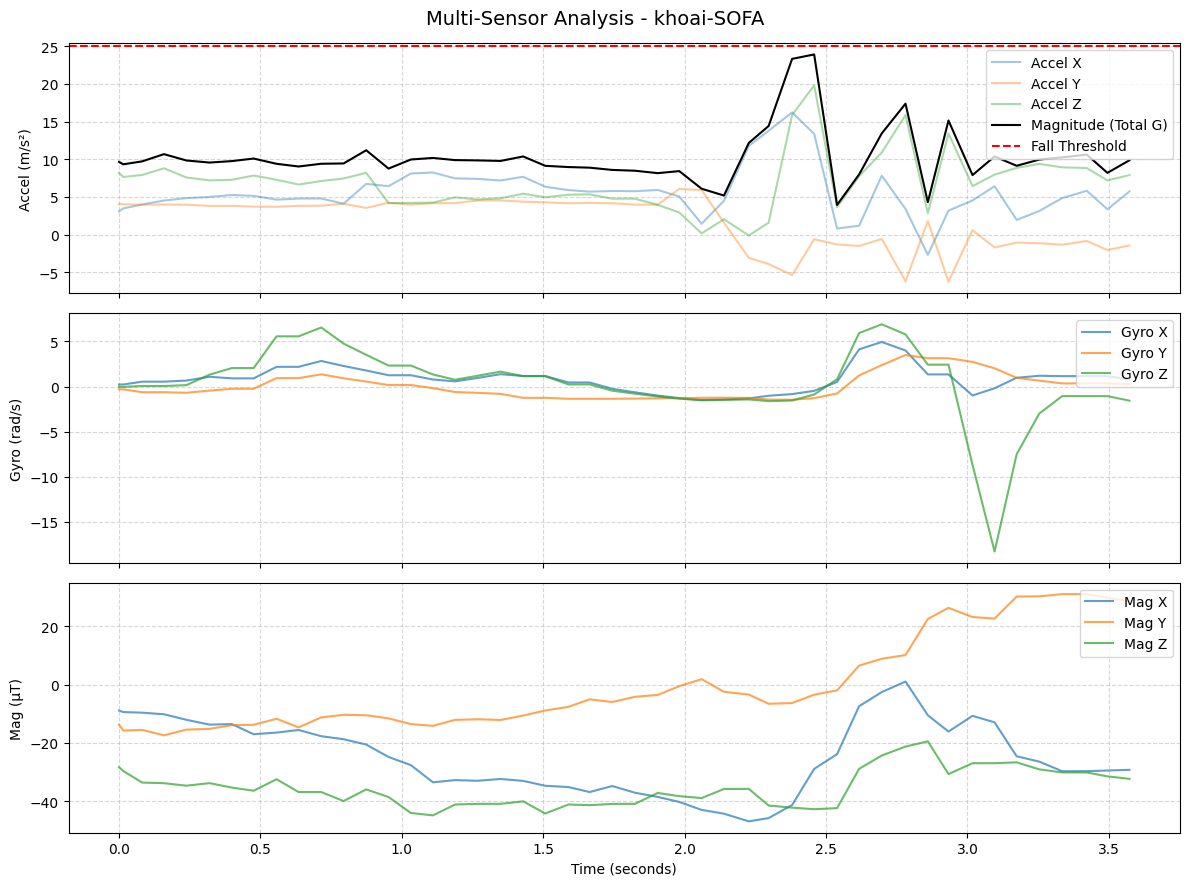

Exported to: D:\khoai-SOFA\ai-engine\datasets\fall\CPH2407_1775814616370_multisensor.png


In [2]:
export_graph(r"D:\khoai-SOFA\ai-engine\datasets\fall\CPH2407_1775814616370.csv")

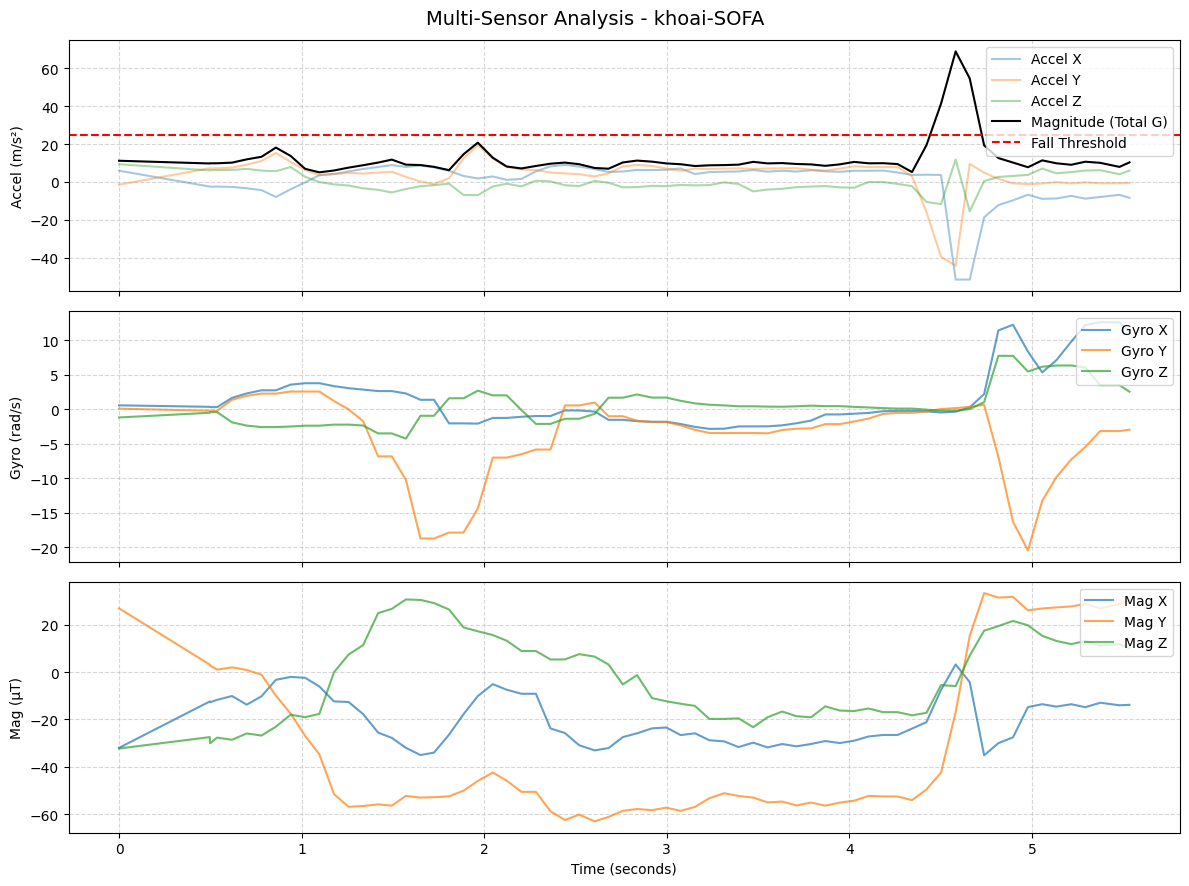

Exported to: D:\khoai-SOFA\ai-engine\datasets\fall\CPH2407_1775815237052_multisensor.png


In [3]:
export_graph(r"D:\khoai-SOFA\ai-engine\datasets\fall\CPH2407_1775815237052.csv")